In [1]:
from urllib.request import urlopen
from bs4 import BeautifulSoup

url = "https://centraldovarejo.com.br/produtos-mais-vendidos-no-mercado-livre/"

html = urlopen(url)

bs = BeautifulSoup(html.read(), "html.parser")

print("Título da página:")
print(bs.title)

print("\nLinks encontrados:\n")

for link in bs.find_all("a", href=True):
    print("link:", link["href"])

Título da página:
<title>Produtos mais vendidos no Mercado Livre: descubra - Central do Varejo</title>

Links encontrados:

link: https://lp.centraldovarejo.com.br/nra2026
link: https://centraldovarejo.com.br
link: https://centraldovarejo.com.br/minha-conta/
link: https://centraldovarejo.com.br/minha-conta/
link: https://centraldovarejo.com.br/calendario-de-eventos/
link: https://centraldovarejo.com.br/quem-somos/
link: https://centraldovarejo.com.br/calendario-de-eventos/
link: https://centraldovarejo.com.br/quem-somos/
link: https://centraldovarejo.com.br/economia/
link: https://centraldovarejo.com.br/operacao/
link: https://centraldovarejo.com.br/franchising/
link: https://centraldovarejo.com.br/inovacao/
link: https://centraldovarejo.com.br/e-commerce/
link: https://centraldovarejo.com.br/marketing/
link: https://centraldovarejo.com.br/opniao/
link: https://centraldovarejo.com.br/opniao/mulheres-do-varejo/
link: https://centraldovarejo.com.br/eventos
link: https://centraldovarejo.c

In [2]:
from urllib.request import urlopen
from bs4 import BeautifulSoup

url = "https://centraldovarejo.com.br/produtos-mais-vendidos-no-mercado-livre/"

html = urlopen(url)
bs = BeautifulSoup(html.read(), "html.parser")

produtos = []

# pega todos os títulos da página
for tag in bs.find_all(["h2","h3"]):
    texto = tag.get_text().strip()

    # pega apenas os que começam com número (1., 2., 3...)
    if texto[0].isdigit():
        produtos.append(texto)

# pegar apenas os 20 primeiros
produtos = produtos[:20]

print("20 produtos mais vendidos:\n")

for i, p in enumerate(produtos, start=1):
    print(i, "-", p)

20 produtos mais vendidos:

1 - 1. Smartphones e celulares
2 - 2. Acessórios para celular
3 - 3. Eletrodomésticos
4 - 4. Informática e tecnologia
5 - 5. TVs e eletrônicos
6 - 6. Casa, móveis e decoração
7 - 7. Moda e acessórios
8 - 8. Beleza e cuidados pessoais
9 - 9. Saúde e bem-estar
10 - 10. Automotivo
11 - 11. Ferramentas e construção
12 - 12. Brinquedos e jogos


In [3]:
from urllib.request import urlopen
from bs4 import BeautifulSoup

url = "https://centraldovarejo.com.br/produtos-mais-vendidos-no-mercado-livre/"

html = urlopen(url)
bs = BeautifulSoup(html.read(), "html.parser")

produtos = []

for tag in bs.find_all(["h2","h3"]):
    texto = tag.get_text().strip()
    
    if texto and texto[0].isdigit():
        nome = texto.split(".",1)[1].strip()
        produtos.append(nome)

for p in produtos[:20]:
    print(p)

Smartphones e celulares
Acessórios para celular
Eletrodomésticos
Informática e tecnologia
TVs e eletrônicos
Casa, móveis e decoração
Moda e acessórios
Beleza e cuidados pessoais
Saúde e bem-estar
Automotivo
Ferramentas e construção
Brinquedos e jogos


In [4]:
from urllib.request import urlopen
from bs4 import BeautifulSoup
import csv

base_url = "https://quotes.toscrape.com/page/{}/"

quotes_list = []

page = 1

while True:
    
    url = base_url.format(page)
    html = urlopen(url)
    soup = BeautifulSoup(html.read(), "html.parser")
    
    quotes = soup.find_all("div", class_="quote")
    
    if not quotes:
        break
    
    for q in quotes:
        quote = q.find("span", class_="text").get_text(strip=True)
        author = q.find("small", class_="author").get_text(strip=True)
        
        quotes_list.append([author, quote])
    
    page += 1


# salvar CSV
with open("quotes.csv", "w", newline="", encoding="utf-8") as f:
    
    writer = csv.writer(f)
    
    writer.writerow(["author", "quote"])
    
    writer.writerows(quotes_list)


print("Arquivo quotes.csv criado com", len(quotes_list), "quotes")

Arquivo quotes.csv criado com 100 quotes


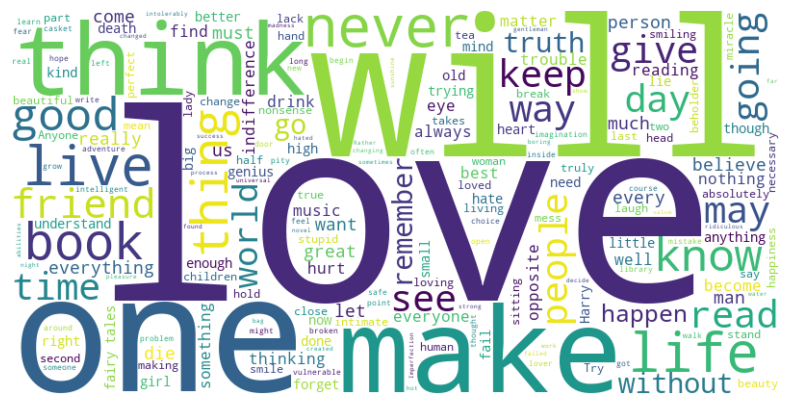

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# carregar o CSV
df = pd.read_csv("quotes.csv")

# juntar todos os quotes em um único texto
text = " ".join(df["quote"])

# palavras comuns para remover
stopwords = set(STOPWORDS)

# gerar wordcloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stopwords
).generate(text)

# mostrar a imagem
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [26]:
from urllib.request import urlopen
from bs4 import BeautifulSoup
import csv

base_url = "https://books.toscrape.com/catalogue/page-{}.html"
site = "https://books.toscrape.com/catalogue/"

books = []

for page in range(1, 51):

    url = base_url.format(page)
    html = urlopen(url)
    soup = BeautifulSoup(html.read(), "html.parser")

    livros = soup.find_all("article", class_="product_pod")

    for livro in livros:

        # titulo
        titulo = livro.h3.a["title"]

        # preço
        preco = livro.find("p", class_="price_color").text

        # avaliação
        avaliacao = livro.find("p", class_="star-rating")["class"][1]

        # link da página do livro
        link = livro.h3.a["href"]
        link = link.replace("../../../", "")
        link = site + link

        # abrir página do livro para pegar categoria
        html_livro = urlopen(link)
        soup_livro = BeautifulSoup(html_livro.read(), "html.parser")

        categoria = soup_livro.find_all("a")[3].text

        books.append([titulo, categoria, avaliacao, preco])


# salvar csv
with open("books.csv", "w", newline="", encoding="utf-8") as f:

    writer = csv.writer(f, delimiter=";")

    writer.writerow(["titulo", "categoria", "avaliacao", "preco"])

    writer.writerows(books)

print("Arquivo books.csv criado com", len(books), "livros")

Arquivo books.csv criado com 1000 livros


In [25]:
from urllib.request import urlopen
from bs4 import BeautifulSoup
import pandas as pd

base_url = "https://books.toscrape.com/catalogue/page-{}.html"

dados = []

for page in range(1, 51):

    url = base_url.format(page)

    html = urlopen(url)

    soup = BeautifulSoup(html.read(), "html.parser")

    livros = soup.find_all("article", class_="product_pod")

    # pegar categoria pelo breadcrumb
    categoria = soup.find("ul", class_="breadcrumb").find_all("li")[1].text.strip()

    for livro in livros:

        titulo = livro.h3.a["title"]

        preco = livro.find("p", class_="price_color").text

        avaliacao = livro.find("p", class_="star-rating")["class"][1]

        dados.append([titulo, categoria, avaliacao, preco])


df = pd.DataFrame(dados, columns=["titulo", "categoria", "avaliacao", "preco"])

df.to_csv("books.csv", sep=";", index=False, encoding="utf-8")

print("CSV criado com", len(df), "livros")

CSV criado com 1000 livros


In [11]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

base_url = "https://www.araujo.com.br/pet-shop?start={}"

dados = []

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

for start in range(0, 500, 12):

    url = base_url.format(start)

    response = requests.get(url, headers=headers)

    soup = BeautifulSoup(response.text, "html.parser")

    produtos = soup.find_all("div", class_="product")

    if not produtos:
        break

    for p in produtos:

        nome = p.find("a", class_="link").get_text(strip=True)

        preco = p.find("span", class_="sales").get_text(strip=True)

        dados.append([nome, preco])


df = pd.DataFrame(dados, columns=["nome_produto", "preco"])

df.to_csv("araujo_petshop.csv", sep=";", index=False)

print("CSV criado com", len(df), "produtos")

CSV criado com 0 produtos


In [12]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.araujo.com.br/pet-shop"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")

produtos = soup.find_all("div", class_="productTile")

dados = []

for p in produtos:

    nome = p.find("h3").get_text(strip=True)

    preco = p.find("span", class_="productPrice__price").get_text(strip=True)

    dados.append([nome, preco])

df = pd.DataFrame(dados, columns=["nome_produto", "preco"])

df.to_csv("araujo_petshop.csv", sep=";", index=False, encoding="utf-8")

print(df)

Empty DataFrame
Columns: [nome_produto, preco]
Index: []


In [13]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd
import time

driver = webdriver.Chrome()

driver.get("https://www.araujo.com.br/pet-shop")

time.sleep(5)

produtos = driver.find_elements(By.CLASS_NAME, "productTile")

dados = []

for p in produtos:

    nome = p.find_element(By.TAG_NAME, "h3").text
    preco = p.find_element(By.CLASS_NAME, "productPrice__price").text

    dados.append([nome, preco])

df = pd.DataFrame(dados, columns=["nome_produto", "preco"])

df.to_csv("araujo_petshop.csv", sep=";", index=False)

print(df)

driver.quit()

                                         nome_produto     preco
0   Ração Úmida para Gatos Friskies Adultos Sabor ...    R$4,59
1   Tapete Higiênico Tico Pads para Cães com 30 Un...   R$38,29
2   Seniox 500 Ômega 3 Para Cães e Gatos Uso Veter...   R$44,89
3   Seniox 1000 Ômega 3 Para Cães e Gatos Uso Vete...   R$72,29
4   Ração para Cão Magnus Todo Dia Raçãs Pequenas ...   R$52,49
5   Ograx Derme 20 para Cães e Gatos 30 Cápsulas G...  R$112,89
6       Oxcell 1000 para Cães e Gatos com 30 Cápsulas   R$84,29
7   NexGard Contra Pulgas e Carrapatos para Cães d...  R$152,39
8   Fralda para Cães Supersecão Descartáveis Fêmea...   R$25,09
9   Shampoo Dermogen de Uso Frequente para Cães e ...   R$84,99
10  Fralda para Cães Fêmeas Super Secão Tamanho M ...   R$31,09
11  Pá Higiênica Pet Injet Cara de Gato Prata Pequena    R$3,29
12  NexGard Combo para Gatos de 2,5kg a 7,5kg Solu...   R$45,69
13  Fralda para Cães Supersecão Descartáveis Macho...   R$31,49
14  Tapete Higiênico para Cães Baby Pads

In [15]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd
import time

driver = webdriver.Chrome()

driver.get("https://www.araujo.com.br/pet-shop")

dados = []

for pagina in range(15):

    time.sleep(5)

    produtos = driver.find_elements(By.CLASS_NAME, "productTile")

    for p in produtos:
        nome = p.find_element(By.TAG_NAME, "h3").text
        preco = p.find_element(By.CLASS_NAME, "productPrice__price").text

        dados.append([nome, preco])

    print("Página", pagina+1, "coletada")

    try:
        botao_proximo = driver.find_element(By.CLASS_NAME, "next")
        botao_proximo.click()
    except:
        break


df = pd.DataFrame(dados, columns=["nome_produto", "preco"])

df.to_csv("araujo_petshop.csv", sep=";", index=False)

driver.quit()

print("Total de produtos:", len(df))

Página 1 coletada
Total de produtos: 48


In [18]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd
import time

driver = webdriver.Chrome()

dados = []

for pagina in range(1, 16):

    url = f"https://www.araujo.com.br/pet-shop?p={pagina}"
    driver.get(url)

    time.sleep(3)

    produtos = driver.find_elements(By.CLASS_NAME, "productTile")

    for p in produtos:

        nome = p.find_element(By.TAG_NAME, "h3").text
        preco = p.find_element(By.CLASS_NAME, "productPrice__price").text

        dados.append([nome, preco])

    print("Página", pagina, "coletada")

driver.quit()

df = pd.DataFrame(dados, columns=["nome_produto", "preco"])

df.to_csv("araujo_petshop.csv", sep=";", index=False)

print("Total de produtos:", len(df))

Página 1 coletada
Página 2 coletada
Página 3 coletada
Página 4 coletada
Página 5 coletada
Página 6 coletada
Página 7 coletada
Página 8 coletada
Página 9 coletada
Página 10 coletada
Página 11 coletada
Página 12 coletada
Página 13 coletada
Página 14 coletada
Página 15 coletada
Total de produtos: 48


In [19]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd
import time

driver = webdriver.Chrome()

dados = []

for pagina in range(1, 16):

    start = (pagina-1) * 48

    url = f"https://www.araujo.com.br/pet-shop?start={start}&sz=48&page={pagina}"

    driver.get(url)

    time.sleep(3)

    produtos = driver.find_elements(By.CLASS_NAME, "productTile")

    for p in produtos:

        nome = p.find_element(By.TAG_NAME, "h3").text
        preco = p.find_element(By.CLASS_NAME, "productPrice__price").text

        dados.append([nome, preco])

    print("Página", pagina, "coletada")

driver.quit()

df = pd.DataFrame(dados, columns=["nome_produto","preco"])

df.to_csv("araujo_petshop.csv", sep=";", index=False)

print("Total de produtos:", len(df))

Página 1 coletada
Página 2 coletada
Página 3 coletada
Página 4 coletada
Página 5 coletada
Página 6 coletada
Página 7 coletada
Página 8 coletada
Página 9 coletada
Página 10 coletada
Página 11 coletada
Página 12 coletada
Página 13 coletada
Página 14 coletada
Página 15 coletada
Total de produtos: 48


In [20]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd
import time

driver = webdriver.Chrome()

dados = []

for pagina in range(15):

    start = pagina * 48
    url = f"https://www.araujo.com.br/pet-shop?start={start}"

    driver.get(url)

    time.sleep(3)

    produtos = driver.find_elements(By.CLASS_NAME, "productTile")

    for p in produtos:
        nome = p.find_element(By.TAG_NAME, "h3").text
        preco = p.find_element(By.CLASS_NAME, "productPrice__price").text

        dados.append([nome, preco])

    print("Página", pagina+1, "coletada")

driver.quit()

df = pd.DataFrame(dados, columns=["nome_produto", "preco"])

df.to_csv("araujo_petshop.csv", sep=";", index=False)

print("Total de produtos:", len(df))

Página 1 coletada
Página 2 coletada
Página 3 coletada
Página 4 coletada
Página 5 coletada
Página 6 coletada
Página 7 coletada
Página 8 coletada
Página 9 coletada
Página 10 coletada
Página 11 coletada
Página 12 coletada
Página 13 coletada
Página 14 coletada
Página 15 coletada
Total de produtos: 48


In [21]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd
import time

driver = webdriver.Chrome()

driver.get("https://www.araujo.com.br/pet-shop")

time.sleep(5)

dados = []

for pagina in range(15):

    start = pagina * 48
    url = f"https://www.araujo.com.br/pet-shop?start={start}"

    driver.execute_script(f"window.location.href='{url}'")

    time.sleep(4)

    produtos = driver.find_elements(By.CLASS_NAME, "productTile")

    for p in produtos:
        nome = p.find_element(By.TAG_NAME, "h3").text
        preco = p.find_element(By.CLASS_NAME, "productPrice__price").text

        dados.append([nome, preco])

    print("Página", pagina+1, "coletada")

driver.quit()

df = pd.DataFrame(dados, columns=["nome_produto","preco"])

df.to_csv("araujo_petshop.csv", sep=";", index=False)

print("Total:", len(df))

Página 1 coletada


KeyboardInterrupt: 

In [22]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd
import time

driver = webdriver.Chrome()

driver.get("https://www.araujo.com.br/pet-shop")

time.sleep(5)

dados = []

while True:

    produtos = driver.find_elements(By.CLASS_NAME, "productTile")

    for p in produtos:
        nome = p.find_element(By.TAG_NAME, "h3").text
        preco = p.find_element(By.CLASS_NAME, "productPrice__price").text
        dados.append([nome, preco])

    print("Produtos coletados:", len(dados))

    try:
        botao_next = driver.find_element(By.CSS_SELECTOR, "li.next-page a")
        driver.execute_script("arguments[0].click();", botao_next)

        time.sleep(4)

    except:
        print("Última página alcançada")
        break


driver.quit()

df = pd.DataFrame(dados, columns=["nome_produto", "preco"])

df.to_csv("araujo_petshop.csv", sep=";", index=False)

print("Total de produtos:", len(df))

Produtos coletados: 48
Produtos coletados: 48
Última página alcançada
Total de produtos: 48


In [24]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd
import time

driver = webdriver.Chrome()

driver.get("https://www.araujo.com.br/pet-shop")

time.sleep(5)

dados = []

while True:

    produtos = driver.find_elements(By.CLASS_NAME, "productTile")

    for p in produtos:
        nome = p.find_element(By.TAG_NAME, "h3").text
        preco = p.find_element(By.CLASS_NAME, "productPrice__price").text
        dados.append([nome, preco])

    print("Produtos coletados:", len(dados))

    try:
        next_button = driver.find_element(By.CSS_SELECTOR, "li.next-page a")
        next_link = next_button.get_attribute("href")

        driver.get(next_link)

        time.sleep(4)

    except:
        print("Última página alcançada")
        break


driver.quit()

df = pd.DataFrame(dados, columns=["nome_produto", "preco"])

df.to_csv("araujo_petshop.csv", sep=";", index=False)

print("Total de produtos:", len(df))

Produtos coletados: 48
Produtos coletados: 48
Última página alcançada
Total de produtos: 48
